# Final Project
**Members:** Kris Nguyen, Anh Nguyen

# Thesis Statement:
Horror is the most "successful" genre in Hollywood, in other words, it produces the highest Return on Investment (ROI) regardless of critical reviews.

### I. Data Preparation and Preprocessing

Data set source: https://github.com/GettysburgDataScience/datasets/blob/main/movies/imdb_movies.csv

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# loading data
url = "https://raw.githubusercontent.com/GettysburgDataScience/datasets/main/movies/imdb_movies.csv"
df = pd.read_csv(url)

In [4]:
# data cleaning
df = df.dropna(subset=['budget_x', 'revenue', 'score', 'genre'])
df = df.query('budget_x >= 100000')

# creating ROI column through the given formula
df['ROI'] = (df['revenue'] - df['budget_x']) / df['budget_x']

# 9 basic genres
genres = ['Action', 'Comedy', 'Drama', 'Fantasy', 'Horror', 'Mystery', 'Romance', 'Thriller', 'Western']

# string-based match to find Horror films
for genre in genres:
    df[genre] = df['genre'].str.contains(genre)

### II. Figures and Analysis

#### Figure 1: Average ROI by Genre 

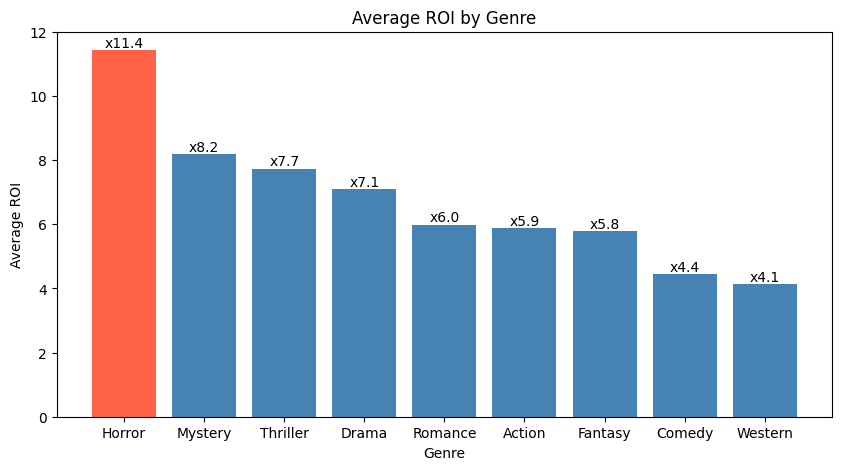

In [16]:
# for each genre, calculate the average ROI
avg_rois = {}
for g in genres:
    avg_rois[g] = df[df[g]]['ROI'].mean()

# create a dictionary to store film genres and their corresponding ROI 
# sorted from high to low
avg_rois = dict(sorted(avg_rois.items(), key=lambda x: x[1], reverse=True))

# assign orange to Horror bar only
colors = []
for g in avg_rois:
    if g == 'Horror':
        colors.append('tomato')
    else:
        colors.append('steelblue')

# plot bar chart: x (keys), y (ROI)
plt.figure(figsize=(10, 5))
bars = plt.bar(avg_rois.keys(), avg_rois.values(), color=colors)

plt.title('Average ROI by Genre')
plt.xlabel('Genre')
plt.ylabel('Average ROI')

# adding labels
for bar in bars:
    y = bar.get_height()                            
    plt.text(bar.get_x() + bar.get_width() / 2,     # x pos
             y,                                     # y pos
             f"x{y:.1f}",                           # formatted text
             ha='center', 
             va='bottom'
    )

plt.show()

#### Figure 2: Average production budget

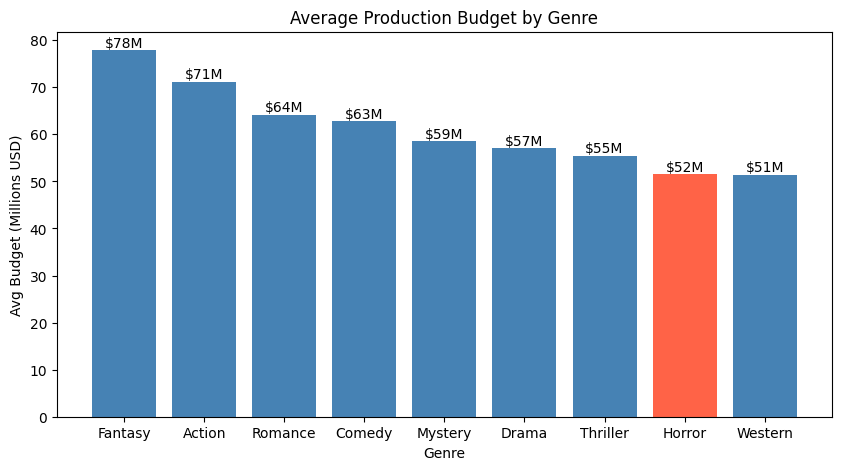

In [17]:
# calculate average budget for each genre
# dollars to millions
avg_budgets = df[genres].multiply(df['budget_x'], axis=0).sum() / df[genres].sum()
avg_budgets = avg_budgets / 1e6

# high to low
avg_budgets = avg_budgets.sort_values(ascending=False)

# highlight Horror by coloring tomato
colors = ['tomato' if g == 'Horror' else 'steelblue' for g in avg_budgets.index]

plt.figure(figsize=(10, 5))
bars = plt.bar(avg_budgets.index, avg_budgets.values, color=colors)

plt.title('Average Production Budget by Genre')
plt.xlabel('Genre')
plt.ylabel('Avg Budget (Millions USD)')

# add labels 
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, # x pos
        y,                                 # y pos
        f'${y:.0f}M',                      # text
        ha='center',
        va='bottom'
    )

plt.show()

#### Figure 3: ROI Distributions for Horror Films

/var/folders/n_/z3k6p59n04s5zn2_bw06m2_h0000gn/T/ipykernel_65097/33535790.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['Genre'] = genre     # genre label
/var/folders/n_/z3k6p59n04s5zn2_bw06m2_h0000gn/T/ipykernel_65097/33535790.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['Genre'] = genre     # genre label
/var/folders/n_/z3k6p59n04s5zn2_bw06m2_h0000gn/T/ipykernel_65097/33535790.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

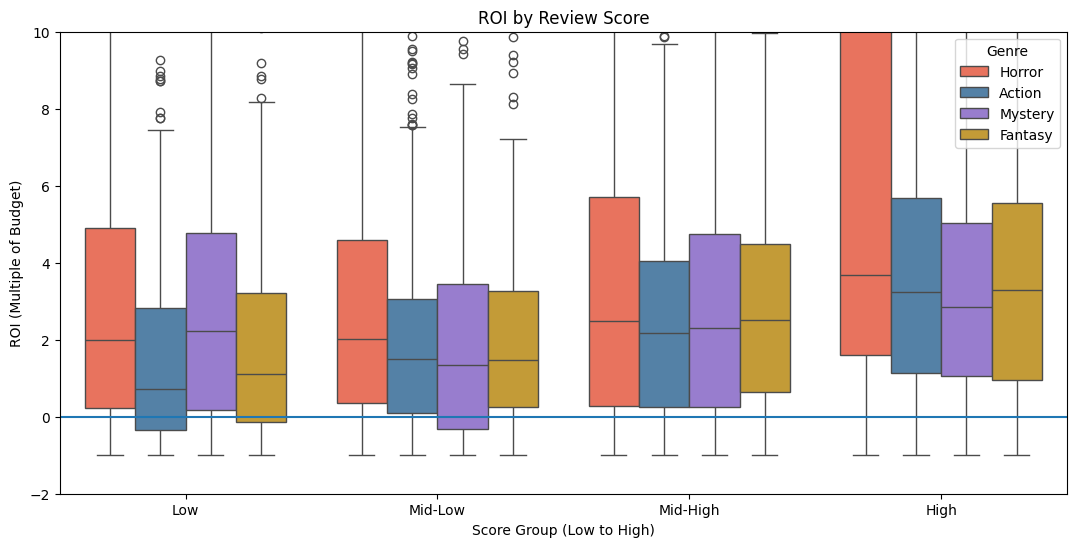

In [32]:
# only looking at the most significant genres
selected = ['Horror', 'Action', 'Mystery', 'Fantasy']

# combined dataset
combined = pd.DataFrame()
for genre in selected:
    temp = df[df[genre]]      # filter to the corresponding genre
    temp['Genre'] = genre     # genre label
    combined = pd.concat([combined, temp])

# divide score group into 4
combined['score_group'] = pd.qcut(
    combined['score'], 4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)

# plot side-by-side boxplots
plt.figure(figsize=(13, 6))
sns.boxplot(
    x='score_group', y='ROI',
    hue='Genre',
    data=combined,
    palette={
        'Horror': 'tomato',
        'Action': 'steelblue',
        'Mystery': 'mediumpurple',
        'Fantasy': 'goldenrod'
    }
)

plt.axhline(0)
plt.ylim(-2, 10)
plt.title('ROI by Review Score')
plt.xlabel('Score Group (Low to High)')
plt.ylabel('ROI (Multiple of Budget)')
plt.legend(title='Genre')
plt.show()